# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Vladimir Aduama
**Student ID:** 59052028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Importing libraries for splitting dataset, standardize numerical data and replace missing values
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder


# Importing different regressors for regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Importing classifiers for classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# Metrics for analyzing data
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

(41202, 13)

   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1      

(0.0, 30.0)

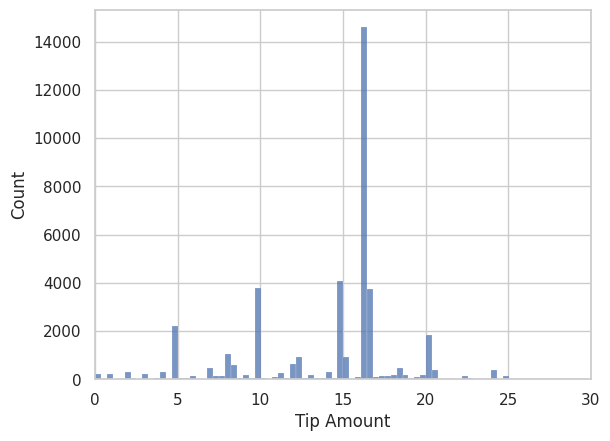

In [2]:
# Taxi Data Set Initialization
taxi = pd.read_csv(TAXI_URL)


# Inspecting Data Set
print(taxi.shape)

print()

print(taxi.head())

print()

taxi.info()

print()

print(taxi.describe())

print("Missing values per column:")
print(taxi.isna().sum())

print()


print("Skewness:")
skewness = taxi['tip_amount'].skew()
print(skewness)
print()



# Visualizaing the distribution of the data
sns.histplot(
    data = taxi,
    x = 'tip_amount'
    )

plt.xlabel("Tip Amount")
plt.xlim(0, 30)

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:**

The dataset consists of 41,202 rows and 13 columns. It is made up of mainly numeric features.

There are no missing values per the results of the .isna().sum() command however there seems to be some impossible values such as 0.00 as a datapoint for trip_distance.


The distribution is skewed to the left. It does not seem to have any visible outliers however the descriptive analysis stated that the max value within the tip_amount feature was 98.0 which is an outlier.
There are a few zeroes within the distribution captured on the histogram.


To ensure that the data is ready for machine learning, the outlier of 98.00 in tip_amount must be clipped and the 0.00 data must be removed.






### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [3]:
# PREPROCESSING
# Cleaning
taxi_clean = taxi.copy()

# Checking the usability of store_and_fwd_flag
print(taxi['store_and_fwd_flag'].value_counts())
taxi_clean = taxi_clean.drop(columns=['store_and_fwd_flag'])

taxi_clean = taxi_clean[
    (taxi_clean['trip_distance'] > 0) &
    (taxi_clean['fare_amount'] > 0) &
    (taxi_clean['tip_amount'] >= 0)
]

taxi_clean = taxi_clean[taxi_clean['tip_amount'] <= 50]


# Feature Engineering
taxi_clean["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]


# Classification of Features
# Numerical vs categorical columns
num_cols = taxi_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = taxi_clean.select_dtypes(include="object").columns.tolist()

print(f"Numerical data type features ({len(num_cols)}): {num_cols}")
print(f"\nCategorical data type features ({len(cat_cols)}): {cat_cols}")


# Manual Classification
id_cols = ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']
for col in id_cols:
    if col in num_cols:
        num_cols.remove(col)
        cat_cols.append(col)

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")



# Categorical Encoding
# One-hot encoding of categorical features
taxi_clean = pd.get_dummies(taxi_clean, columns=cat_cols, drop_first=True, dtype=int)




store_and_fwd_flag
1    41177
0       25
Name: count, dtype: int64
Numerical data type features (13): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'fare_per_mile']

Categorical data type features (0): []
Numerical features (9): ['passenger_count', 'trip_distance', 'payment_type', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'fare_per_mile']

Categorical features (4): ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**

This dataset had no missing values however numeric columns were clipped to remove outliers. Additionally, other numeric columns were set to a minimum above 0 to prevent division by zero errors or impossible values such as distance = 0.


The fare per mile feature was engineered and it basically captures some traffic conditions. High fare-per-mile could indicate heavy traffic where the taxi was idling or moving slowly. On the other hand, low fare-per-mile could indicate a smooth and fast trip.

The standard scaler was chosen because outliers were removed and the distribution of tip_amount was only slightly left_skewed but fairly normal (bell curved).


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [4]:
# Separating features
X = taxi_clean.drop(columns=['tip_amount'])
y_reg = taxi_clean['tip_amount']


# Splitting off the TEST set (20% of the entire dataset)
X_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_train_temp,
    test_size=0.25,
    random_state=42
)

# Initializing and fit scaler on TRAINING features only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transforming the validation and test features using the training metrics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Regression Shapes - Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Regression Shapes - Train: 24659 | Val: 8220 | Test: 8220


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:**

I utilized a 60/20/20 ratio for the train, validation, and test splits. The validation set works as a temporary testing ground before the actual testing phase.

If the scaler were to be fitted on the entire data set, it would essentially peak into the data and gain some information about it. This would make it seem to predict the dataset better rather than actually generating valid outputs. It's known as data leakage

### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

In [5]:
regressor = LinearRegression()

regressor.fit(X_train_scaled, y_train)


y_train_pred = regressor.predict(X_train_scaled)
y_val_pred = regressor.predict(X_val_scaled)
y_test_pred = regressor.predict(X_test_scaled)


train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print ("RMSE Report")
print(f"Training RMSE:   {train_rmse}")
print(f"Validation RMSE: {val_rmse}")
print(f"Testing RMSE:    {test_rmse}")

print()
print("R^2 report")
print(f"Training R^2:   {train_r2}")
print(f"Validation R^2: {val_r2}")
print(f"Testing R^2:    {test_r2}")

RMSE Report
Training RMSE:   4.582197018218779
Validation RMSE: 4.486201206110138
Testing RMSE:    4.557794244944132

R^2 report
Training R^2:   0.06701150802069855
Validation R^2: 0.0482790464961137
Testing R^2:    0.05615473554634953


**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**

The simple linear regression was used and there are no hyper parameters to be used.


The RMSE metrics for each of the set were relatively consistent. These numbers indicate that there is no overfitting.

The low R^2 suggests that a line cannot fully capture the relationship though.

If the model were overfitting, I would apply regularization techniques to penalize large weights.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Dataset Shape: (2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Pub

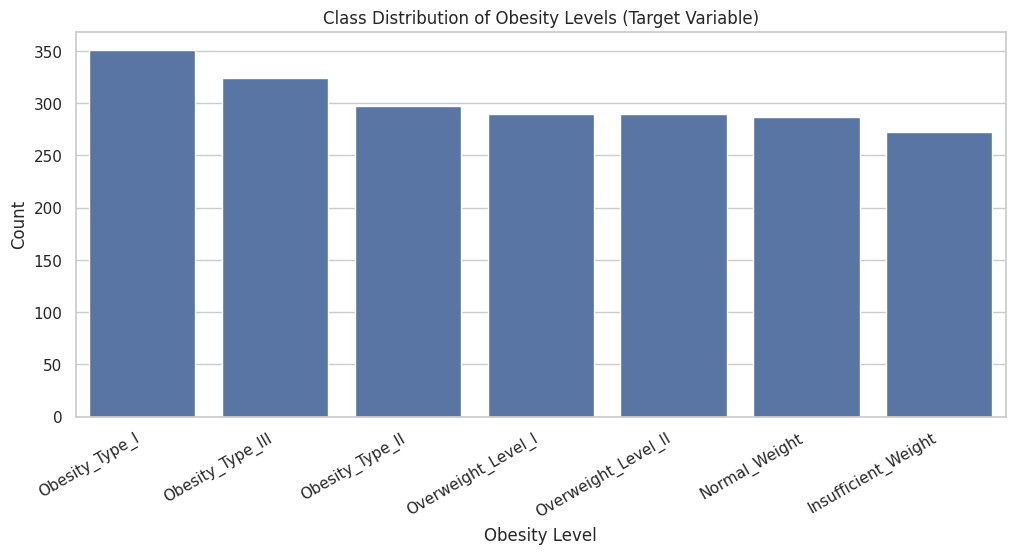

In [6]:
obesity = pd.read_csv(OBESITY_URL)

print("Dataset Shape:", obesity.shape)


print(obesity.head())


print("Dataset Information")
obesity.info()


print("Summary Statistics")
print(obesity.describe(include='all'))


print("Missing Values ")
print(obesity.isna().sum())


print(" Class Distribution of NObeyesdad ")
print(obesity['NObeyesdad'].value_counts())


print("Visualizing Class Distribution")
plt.figure(figsize=(12, 5))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title("Class Distribution of Obesity Levels (Target Variable)")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:**

The dataset contains 2,111 rows and 17 columns
There are 8 numerical columns:

Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE

There are 9 categorical columns:

Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and the target NObeyesdad


Yes its relatively balanced between the 7 classes. It's important because it prevents the model from predicting values that are biased towards a domninant class.


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [7]:
# Encoding Binary Columns
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

## Encode Ordinal Columns (Categorical with an order)
# Mapping eating/drinking habits to a logical scale
order_mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(order_mapping)
obesity['CALC'] = obesity['CALC'].map(order_mapping)

# Encode Nominal Columns (Categorical without an inherent order)
nominal_cols = ['Gender', 'MTRANS']
obesity = pd.get_dummies(obesity, columns=nominal_cols, drop_first=True, dtype=int)

# Feature Engineering: Calculating BMI
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# Encoding the Target Column
target_encoder = LabelEncoder()
obesity['NObeyesdad'] = target_encoder.fit_transform(obesity['NObeyesdad'])

**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:**

Binary models were mapped to a simple 0 or 1. Ordinal were mapped to a integer sequence from 0 to 3 ranging from "no" to "always". Nominal columns were encoded with pd.get_dummies.

It's fair because the feature would not cause data leakage.

I selected StandardScaler to normalize the data because continuous features like Weight and Age possess radically different raw scalar magnitudes.

### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [8]:
## Separating features
X_obesity = obesity.drop(columns=['NObeyesdad'])
y_obesity = obesity['NObeyesdad']

## First split: Test set (20%) using stratification
X_temp, X_test, y_temp, y_test = train_test_split(
    X_obesity, y_obesity,
    test_size=0.2,
    random_state=42,
    stratify=y_obesity
)

## Second split:  Train (60%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

## Fitting the scaler on the training set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

## Transform validation and test sets using training metrics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print(f"Train set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Train set: 1266 rows
Validation set: 422 rows
Test set: 423 rows


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:**

I chose a 60/20/20 split ratio for training, validation and testing respectively.


Stratification ensures that the balance of the 7 obesity classes remains the same across all three splits. This allows each class to be equally represented in the different splits.


If a split is done without stratification, some classes may be extremely over represented or under represented leading to bias.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Accuracy Scores
Train:  1.0
Validation:  0.990521327014218
Test:  0.9976359338061466

Macro-F1 Scores
Train:      1.0000
Validation: 0.9901
Test:       0.9975


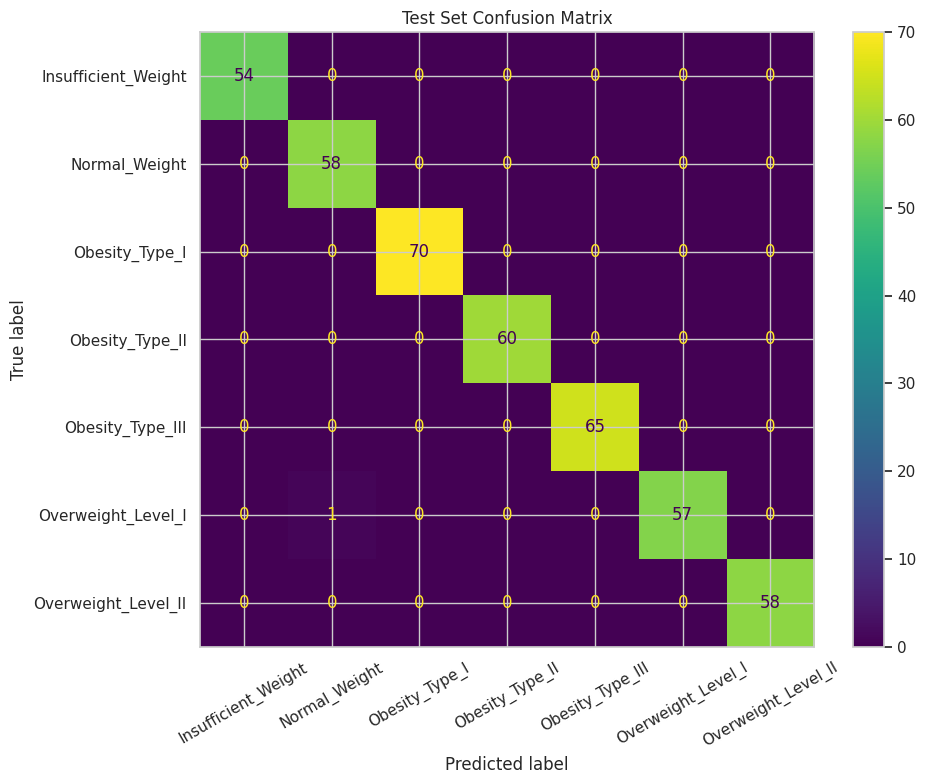

In [9]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

## Model Training
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train_scaled, y_train)

## Predictions
y_train_pred = clf.predict(X_train_scaled)
y_val_pred = clf.predict(X_val_scaled)
y_test_pred = clf.predict(X_test_scaled)

## Metrics
print("Accuracy Scores")
print("Train: " , accuracy_score(y_train, y_train_pred))
print("Validation: ",  accuracy_score(y_val, y_val_pred))
print("Test: " , accuracy_score(y_test, y_test_pred))

print("\nMacro-F1 Scores")
print(f"Train:      {f1_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"Validation: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Test:       {f1_score(y_test, y_test_pred, average='macro'):.4f}")

## Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=target_encoder.classes_,
    xticks_rotation=30,
    ax=ax
)
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**

I chose a Random Forest Classifier that handles non-linear relationships and simple configurations.

The model is well fitted per the metrics produced.

The matrix doesn't show much confusion between the classifications however the overweight level 1 and normal weight were missclassified. This may be due them being adjacent to each other.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


Text(0.5, 1.0, 'K-Means Clusters')

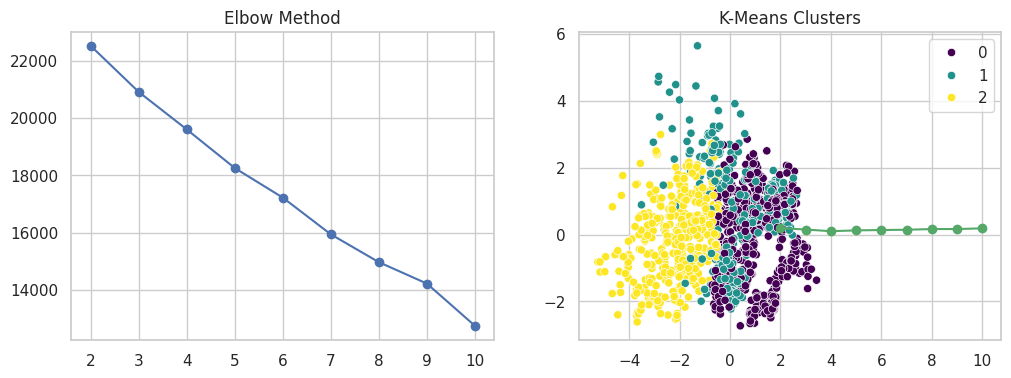

In [10]:
# K MEANS

inertia = []
silhouette = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_train_scaled, km.labels_))

# Plot both charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertia, marker='o')
ax1.set_title("Elbow Method")
ax2.plot(k_range, silhouette, marker='o', color='g')
ax2.set_title("Silhouette Scores")


print()

# Fit model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_train_scaled)

# Reduce to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# Plot clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis')
plt.title("K-Means Clusters")


In [11]:
true_labels_text = target_encoder.inverse_transform(y_train)

# Creating the crosstab table
alignment_table = pd.crosstab(
    index=labels,
    columns=true_labels_text,
    rownames=['K-Means Cluster'],
    colnames=['True Obesity Class']
)

# Displaying the matrix
print(alignment_table)


True Obesity Class  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
K-Means Cluster                                                          
0                                     0             14             140   
1                                    32             35              67   
2                                   131            123               4   

True Obesity Class  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
K-Means Cluster                                                             
0                               124               194                  71   
1                                53                 0                  48   
2                                 1                 0                  55   

True Obesity Class  Overweight_Level_II  
K-Means Cluster                          
0                                    70  
1                                    64  
2                                    40  


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:**

K-Means was not able to isolate the differences between different classes but could capture the progression from low weight to high weight.


Although the plot of the elbow method looked like a downward line without any clear bend at a specific K, a K of 3 was chosen cause the largest dip occurred between 2 and 3.

The unsupervised clusters separate the extremes well. Cluster 0 captures the heaviest groups, while Cluster 2 isolates the lightest groups.

These clusters are useful for risk triaging. Instead of expensive clinical assessments, a public health team can use free, unlabeled survey data to instantly group a population into high, medium, and low-risk pools.


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:**

The Random Forest classifier learned the specific, labeled medical boundaries separating the 7 obesity classes, allowing it to predict precise health risk levels.

K-Means discovered the broader, unlabeled geometric structure of the data, grouping people into weight tiers (low, medium, high) based purely on feature distance rather than medical definitions.


Regression vs Classification:

Regression was heavily focused on ensuring numerical data was accurate and scaled properly while classification focused mainly on esnuring that classes were well represented and grouped. For instance, there was more in depth preprocessing in regression compared to classification. Furthermore, classification seemed to employ more graphs for visualizing the different classes.



Biggest train-vs-test gap:

The linear regression model for tip prediction showed the most significant performance gap, it was heavily underfitting because a straight line couldn't capture the true shape of the data. To fix any gaps, I would  use regularization methods to reduce complex features and ensure that training and testing gaps are minimized.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
